# InceptionTime - SOTA deep learning for TS

In [1]:
# %%
import os
import sys
import time
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef, brier_score_loss,
                             ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

# Call it immediately
set_seed(42)

# --- Project Root Setup ---
def find_project_root(name='Bambino', start=None):
    if start is None: start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name: return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir: return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
if PROJECT_ROOT: sys.path.append(PROJECT_ROOT)

from config import settings
import config_inception as cfg

try:
    from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
except ImportError:
    raise ImportError("Could not import BoaOpenFaceDataset.")

from _utils_ import dataset_utils

# --- Configuration ---
OUT_DIR = Path("./results_InceptionTime") if cfg.dataset_type == "normalized" else Path("./results_InceptionTime_augmented")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_LEN = cfg.TARGET_LEN          
BATCH_SIZE = cfg.BATCH_SIZE
NUM_EPOCHS = cfg.NUM_EPOCHS
LR = cfg.LR
WEIGHT_DECAY = cfg.WEIGHT_DECAY
PATIENCE = cfg.PATIENCE              
DEVICE = cfg.DEVICE
PRINT_EVERY = cfg.PRINT_EVERY
MODALITIES = cfg.MODALITIES
numeric_features = cfg.numeric_features
cat_features = cfg.cat_features

# %% --- Data Helpers ---
def ds_to_numpy_and_meta(ds, modalities=MODALITIES, target_len=TARGET_LEN):
    modality_map = {'g': 'gaze_info', 'h': 'head_info', 'f': 'face_info'}
    X_list, metas = [], []
    
    for inst in ds.instances:
        mats = []
        for m in modalities:
            attr = modality_map[m]
            mat = getattr(inst, attr)
            mats.append(np.asarray(mat))
        
        X = np.concatenate(mats, axis=1)
        L = X.shape[0]
        
        if L >= target_len:
            start = (L - target_len) // 2
            X_t = X[start:start+target_len, :]
        else:
            pad = np.zeros((target_len - L, X.shape[1]), dtype=X.dtype)
            X_t = np.vstack([X, pad])
            
        X_list.append(X_t.T)
        
        age = float(inst.age) if inst.age is not None else np.nan
        meta_row = {
            'pt_id': inst.pt_id,
            'trial_id': inst.trial_id,
            'label': int(inst.trial_type),
            'age': age,
            'sex': inst.sex if hasattr(inst, 'sex') else np.nan,
            'duration_s': L / getattr(ds, "FRAME_RATE", 25)
        }
        metas.append(meta_row)
        
    X_arr = np.stack(X_list, axis=0).astype(np.float32)
    meta_df = pd.DataFrame(metas)
    return X_arr, meta_df

# %% --- Load Data ---
print("\n📂 Loading datasets...") 
TRAIN_PATH = settings.get_dataset_path(cfg.dataset_type, settings.training_filename)
VAL_PATH = settings.get_dataset_path(cfg.dataset_type, settings.validation_filename)
TEST_PATH = settings.get_dataset_path(cfg.dataset_type, settings.test_filename)

train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
val_ds   = BoaOpenFaceDataset.load_dataset(VAL_PATH)
test_ds  = BoaOpenFaceDataset.load_dataset(TEST_PATH)

print(f"Instances: Train {len(train_ds)}, Val {len(val_ds)}, Test {len(test_ds)}")

# Convert
X_train_ts, df_train_meta = ds_to_numpy_and_meta(train_ds)
X_val_ts,   df_val_meta   = ds_to_numpy_and_meta(val_ds)
X_test_ts,  df_test_meta  = ds_to_numpy_and_meta(test_ds)

y_train = df_train_meta['label'].values
y_val   = df_val_meta['label'].values
y_test  = df_test_meta['label'].values

# Metadata
print("   Processing Metadata...")
meta_preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='drop'
)

X_meta_train = meta_preproc.fit_transform(df_train_meta[numeric_features + cat_features])
X_meta_val   = meta_preproc.transform(df_val_meta[numeric_features + cat_features])
X_meta_test  = meta_preproc.transform(df_test_meta[numeric_features + cat_features])

# Save Artifacts
import joblib
joblib.dump(meta_preproc, OUT_DIR/"meta_preproc.joblib")

# %% --- PyTorch Loaders ---
def build_loader(X_ts, X_meta, y, batch_size=BATCH_SIZE, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_ts, dtype=torch.float32),
        torch.tensor(X_meta, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = build_loader(X_train_ts, X_meta_train, y_train, shuffle=True)
val_loader   = build_loader(X_val_ts, X_meta_val, y_val, shuffle=False)
test_loader  = build_loader(X_test_ts, X_meta_test, y_test, shuffle=False)



📂 Loading datasets...
Instances: Train 1970, Val 140, Test 137
   Processing Metadata...


## Model and Training

In [2]:
# %% [markdown]
# # InceptionTime + Metadata Fusion Training Pipeline
# 
# **Goal:** Classify infant movement using InceptionTime (End-to-End) on raw time series.
# **Alignment:** Mirrors the robust logic of the ResNet18 pipeline.

# %%
import copy
import torch.optim as optim

# --- 1. Configuration & Reproducibility ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
# 
# Note: Ensure your data loaders (train_loader, val_loader, test_loader) 
# return (X_series, X_meta, y) tuple.
# Assuming X_train_ts, X_meta_train, y_train etc. are already loaded in memory.

print(f"Device: {DEVICE}")

# %% [markdown]
# ## 2. Model Definition (InceptionTime)

# %%
class InceptionModule(nn.Module):
    def __init__(self, in_channels, nb_filters, kernel_size, bottleneck_size, activation=nn.ReLU()):
        super().__init__()
        
        # 1. Bottleneck
        if in_channels > 1 and bottleneck_size is not None:
            self.bottleneck = nn.Conv1d(in_channels, bottleneck_size, 1, bias=False)
            input_channels = bottleneck_size
        else:
            self.bottleneck = nn.Identity()
            input_channels = in_channels
            
        # 2. Parallel Convolutions
        k1 = kernel_size
        k2 = kernel_size // 2 + 1
        k3 = kernel_size // 4 + 1
        
        self.conv1 = nn.Conv1d(input_channels, nb_filters, k1, padding=k1//2, bias=False)
        self.conv2 = nn.Conv1d(input_channels, nb_filters, k2, padding=k2//2, bias=False)
        self.conv3 = nn.Conv1d(input_channels, nb_filters, k3, padding=k3//2, bias=False)
        
        # 3. Max Pooling
        self.maxpool = nn.MaxPool1d(3, stride=1, padding=1)
        self.conv_pool = nn.Conv1d(in_channels, nb_filters, 1, bias=False)
        
        self.bn = nn.BatchNorm1d(nb_filters * 4)
        self.act = activation

    def forward(self, x):
        x_in = x
        x_bottle = self.bottleneck(x)
        target_len = x.shape[-1]
        
        out1 = self.conv1(x_bottle)[..., :target_len]
        out2 = self.conv2(x_bottle)[..., :target_len]
        out3 = self.conv3(x_bottle)[..., :target_len]
        out_pool = self.conv_pool(self.maxpool(x_in))[..., :target_len]
        
        out = torch.cat([out1, out2, out3, out_pool], dim=1)
        out = self.bn(out)
        return self.act(out)

class InceptionBlock(nn.Module):
    def __init__(self, in_channels, nb_filters, kernel_size, bottleneck_size, depth, use_residual):
        super().__init__()
        self.use_residual = use_residual
        self.depth = depth
        self.modules_list = nn.ModuleList()
        
        for d in range(depth):
            curr_in = in_channels if d == 0 else nb_filters * 4
            self.modules_list.append(InceptionModule(curr_in, nb_filters, kernel_size, bottleneck_size))
            
        if self.use_residual:
            self.shortcut = nn.Conv1d(in_channels, nb_filters * 4, 1, bias=False)
            self.bn_shortcut = nn.BatchNorm1d(nb_filters * 4)

    def forward(self, x):
        res = x
        for d in range(self.depth):
            x = self.modules_list[d](x)
            
        if self.use_residual:
            res = self.shortcut(res)
            res = self.bn_shortcut(res)
            x = torch.relu(x + res)
        return x

class InceptionTimeWithMeta(nn.Module):
    def __init__(self, in_channels, meta_dim, nb_filters=32, depth=6, kernel_size=40, bottleneck_size=32, num_classes=1):
        super().__init__()
        self.inception_block = InceptionBlock(in_channels, nb_filters, kernel_size, bottleneck_size, depth, True)
        self.gap = nn.AdaptiveAvgPool1d(1)
        
        # Fusion Head
        feat_dim = nb_filters * 4
        total_dim = feat_dim + meta_dim
        
        self.head = nn.Sequential(
            nn.Linear(total_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5), # High dropout
            nn.Linear(64, num_classes)
        )

    def forward(self, x, meta):
        x = self.inception_block(x)
        x = self.gap(x).squeeze(-1)
        x = torch.cat([x, meta], dim=1)
        return self.head(x).squeeze(-1)

# Initialize Model
# NOTE: Ensure input shapes match your data!
# Example: input_channels = 38 (OpenFace channels), meta_dim = 2 (Age, Sex)
model = InceptionTimeWithMeta(
    in_channels=X_train_ts.shape[1], 
    meta_dim=X_meta_train.shape[1],
    nb_filters=32, depth=6
).to(DEVICE)

# %% [markdown]
# ## 3. Optimization Setup (Matches ResNet)

# %%
# 1. Calculate Pos_Weight for Imbalance Handling
# Assuming y_train is a numpy array or tensor on CPU
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
pos_weight_val = num_neg / num_pos if num_pos > 0 else 1.0
pos_weight_tensor = torch.tensor([pos_weight_val]).float().to(DEVICE)
print(f"Calculated pos_weight: {pos_weight_val:.2f}")

# 2. Loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# 3. Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# 4. Scheduler (Cosine Annealing)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# %% [markdown]
# ## 4. Training Loop (Cosine Strategy)

# %%
best_model_wts = copy.deepcopy(model.state_dict())
best_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

print(f"🚀 Starting training for {NUM_EPOCHS} epochs (Cosine Schedule)...")

for epoch in range(NUM_EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    
    for xb, xm, yb in train_loader:
        xb, xm, yb = xb.to(DEVICE), xm.to(DEVICE), yb.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(xb, xm)
        loss = criterion(outputs, yb)
        loss.backward()
        
        # Clip Gradients (Crucial for InceptionTime depth)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
        
    epoch_train_loss = train_loss / len(train_loader.dataset)
    
    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    val_probs_list = []
    val_labels_list = []
    
    with torch.no_grad():
        for xb, xm, yb in val_loader:
            xb, xm, yb = xb.to(DEVICE), xm.to(DEVICE), yb.to(DEVICE)
            outputs = model(xb, xm)
            loss = criterion(outputs, yb)
            val_loss += loss.item() * xb.size(0)
            
            # Store for metrics
            val_probs_list.extend(torch.sigmoid(outputs).cpu().numpy())
            val_labels_list.extend(yb.cpu().numpy())
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    
    # Calculate Bal Acc using default 0.5 threshold for monitoring
    val_preds = (np.array(val_probs_list) >= 0.5).astype(int)
    epoch_bal_acc = balanced_accuracy_score(val_labels_list, val_preds)
    
    # Logging
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    
    # Scheduler Step
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1:02d} | LR: {current_lr:.1e} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Bal Acc: {epoch_bal_acc:.4f}", end="")
    
    # Save Best Model (Based on LOSS)
    if epoch_val_loss < best_loss:
        best_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        print("  <-- New Best")
    else:
        print("")

# Load best weights
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "best_inception_model.pth")
print("✅ Training Complete. Best model loaded.")

# %% [markdown]
# ## 5. Threshold Optimization (On Validation)

# %%
print("🔎 Optimizing Threshold on Validation Set...")
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for xb, xm, yb in val_loader:
        xb, xm, yb = xb.to(DEVICE), xm.to(DEVICE), yb.to(DEVICE)
        outputs = model(xb, xm)
        probs = torch.sigmoid(outputs).cpu().numpy()
        val_probs.extend(probs)
        val_labels.extend(yb.cpu().numpy())

val_probs = np.array(val_probs)
val_labels = np.array(val_labels)

best_thr = 0.5
best_bal_acc = 0.0

# Scan thresholds
thresholds = np.linspace(0, 1, 101)
for thr in thresholds:
    preds = (val_probs >= thr).astype(int)
    bal = balanced_accuracy_score(val_labels, preds)
    if bal > best_bal_acc:
        best_bal_acc = bal
        best_thr = thr

print(f"🎯 Best Threshold found: {best_thr:.2f}")
print(f"   Validation Balanced Acc at best thr: {best_bal_acc:.4f}")

Device: cuda
Calculated pos_weight: 0.98
🚀 Starting training for 50 epochs (Cosine Schedule)...
Epoch 01 | LR: 1.0e-03 | Train Loss: 0.5805 | Val Loss: 0.6814 | Val Bal Acc: 0.5179  <-- New Best
Epoch 02 | LR: 1.0e-03 | Train Loss: 0.4100 | Val Loss: 0.6774 | Val Bal Acc: 0.5312  <-- New Best
Epoch 03 | LR: 9.9e-04 | Train Loss: 0.2953 | Val Loss: 0.7921 | Val Bal Acc: 0.5000
Epoch 04 | LR: 9.8e-04 | Train Loss: 0.2042 | Val Loss: 1.3924 | Val Bal Acc: 0.5045
Epoch 05 | LR: 9.8e-04 | Train Loss: 0.1533 | Val Loss: 1.0659 | Val Bal Acc: 0.5714
Epoch 06 | LR: 9.6e-04 | Train Loss: 0.1502 | Val Loss: 0.8760 | Val Bal Acc: 0.5179
Epoch 07 | LR: 9.5e-04 | Train Loss: 0.1258 | Val Loss: 1.3722 | Val Bal Acc: 0.5089
Epoch 08 | LR: 9.4e-04 | Train Loss: 0.0951 | Val Loss: 1.4944 | Val Bal Acc: 0.5536
Epoch 09 | LR: 9.2e-04 | Train Loss: 0.0865 | Val Loss: 1.2281 | Val Bal Acc: 0.5670
Epoch 10 | LR: 9.0e-04 | Train Loss: 0.0859 | Val Loss: 2.9771 | Val Bal Acc: 0.5312
Epoch 11 | LR: 8.9e-04 | T

## Evaluation and Plots


📝 Evaluating on Test Set...

TEST Balanced Accuracy: 0.5163
TEST MCC: 0.0293

Classification Report:
              precision    recall  f1-score   support

         0.0     0.2162    0.2963    0.2500        27
         1.0     0.8100    0.7364    0.7714       110

    accuracy                         0.6496       137
   macro avg     0.5131    0.5163    0.5107       137
weighted avg     0.6930    0.6496    0.6687       137



<Figure size 600x500 with 0 Axes>

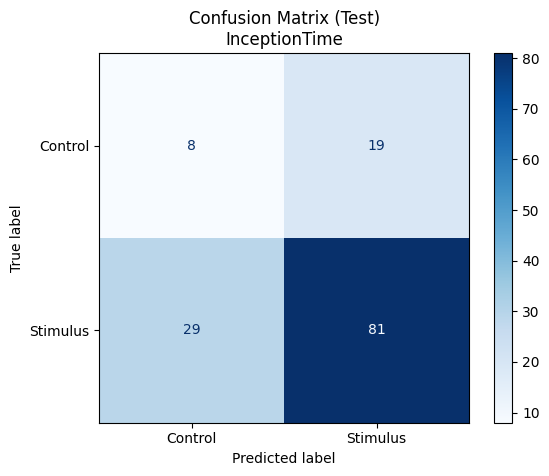

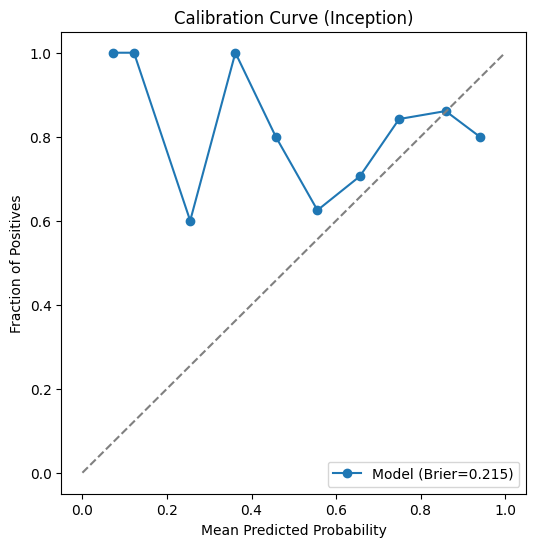


👶 Per-Baby Performance Analysis...

Per-Baby Balanced Accuracy and F1 Scores (Test):
------------------------------------------------------------
BabyID: bam1_005   | Age: 5.42  | Sex: F   | Balanced Accuracy: 0.3438       | F1 Score: 0.7097
BabyID: bam1_044   | Age: 6.08  | Sex: M   | Balanced Accuracy: 0.4062       | F1 Score: 0.7879
BabyID: bam1_018   | Age: 4.96  | Sex: M   | Balanced Accuracy: 0.5000       | F1 Score: 0.6154
BabyID: bam1_020   | Age: 4.83  | Sex: F   | Balanced Accuracy: 0.5000       | F1 Score: 0.7742
BabyID: bam1_008   | Age: 6.70  | Sex: F   | Balanced Accuracy: 0.5333       | F1 Score: 0.7857
BabyID: bam1_024   | Age: 6.41  | Sex: F   | Balanced Accuracy: 0.6250       | F1 Score: 0.9091
BabyID: bam1_026   | Age: 6.54  | Sex: F   | Balanced Accuracy: 0.7188       | F1 Score: 0.7857
------------------------------------------------------------


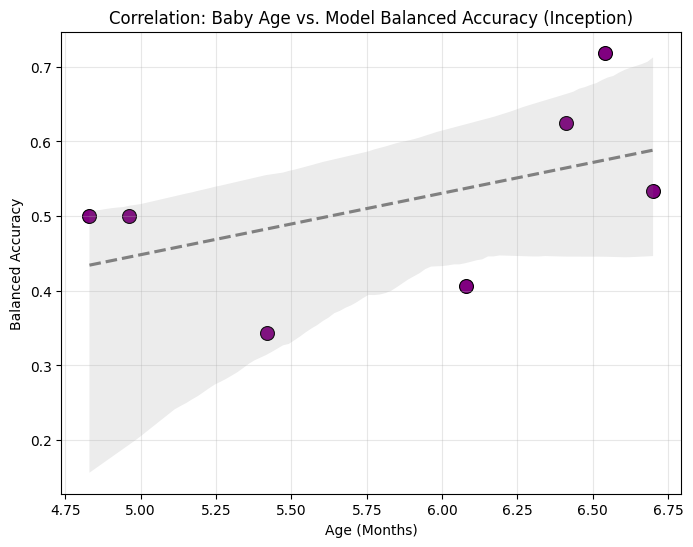


✅ Analysis Complete. Results saved to results_InceptionTime_augmented


In [3]:
# %% --- Evaluation ---
print("\n📝 Evaluating on Test Set...")
model.load_state_dict(best_model_wts)
model.eval()

test_probs, test_labels = [], []
with torch.no_grad():
    for xb, xm, yb in test_loader:
        xb, xm, yb = xb.to(DEVICE), xm.to(DEVICE), yb.to(DEVICE)
        logits = model(xb, xm)
        test_probs.extend(torch.sigmoid(logits).cpu().numpy())
        test_labels.extend(yb.cpu().numpy())

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

y_pred_test = (test_probs >= best_thr).astype(int)
bal_test = balanced_accuracy_score(test_labels, y_pred_test)
mcc_test = matthews_corrcoef(test_labels, y_pred_test)
brier_test = brier_score_loss(test_labels, test_probs)

print(f"\nTEST Balanced Accuracy: {bal_test:.4f}")
print(f"TEST MCC: {mcc_test:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, y_pred_test, digits=4))

# Save Text Report
with open(OUT_DIR / "inception_classification_report_test.txt", "w") as f:
    f.write(classification_report(test_labels, y_pred_test, digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred_test)
plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "Stimulus"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Test)\nInceptionTime")
plt.savefig(OUT_DIR / "inception_confusion_matrix_test.png")
plt.show()

# Calibration
frac_pos, mean_pred = calibration_curve(test_labels, test_probs, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot(mean_pred, frac_pos, marker='o', label=f'Model (Brier={brier_test:.3f})')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Inception)')
plt.legend()
plt.savefig(OUT_DIR / "inception_calibration_curve_test.png")
plt.show()

# Per-Baby Analysis
print("\n👶 Per-Baby Performance Analysis...")
pt_ids = df_test_meta['pt_id'].unique()
per_baby_details = []
per_baby_f1_list = []

df_test_meta['pred_prob'] = test_probs
df_test_meta['pred_label'] = y_pred_test
df_test_meta['true_label'] = test_labels

for pid in pt_ids:
    sub = df_test_meta[df_test_meta['pt_id'] == pid]
    if len(sub) < 2: continue
    f1 = f1_score(sub['true_label'], sub['pred_label'], zero_division=0)
    bal_acc = balanced_accuracy_score(sub['true_label'], sub['pred_label'])
    age = sub['age'].iloc[0]
    sex_val = sub['sex'].iloc[0]
    sex_str = "F" if str(sex_val) == "0" else "M" if str(sex_val) == "1" else str(sex_val)
    per_baby_details.append((pid, age, sex_str, bal_acc, f1))
    per_baby_f1_list.append(f1)

# Sort by Balanced Accuracy
per_baby_details.sort(key=lambda x: x[3])
print("\nPer-Baby Balanced Accuracy and F1 Scores (Test):")
print("-" * 60)
for pid, age, sex, bal_acc, f1 in per_baby_details:
    print(f"BabyID: {pid:<10} | Age: {age:<5.2f} | Sex: {sex:<3} | Balanced Accuracy: {bal_acc:<12.4f} | F1 Score: {f1:.4f}")
print("-" * 60)

# Scatter Plot: Age vs Balanced Accuracy
ages = [x[1] for x in per_baby_details]
bal_accs = [x[3] for x in per_baby_details]
plt.figure(figsize=(8, 6))
sns.scatterplot(x=ages, y=bal_accs, s=100, color='purple', edgecolor='black')
sns.regplot(x=ages, y=bal_accs, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title("Correlation: Baby Age vs. Model Balanced Accuracy (Inception)")
plt.xlabel("Age (Months)")
plt.ylabel("Balanced Accuracy")
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR / "inception_age_vs_balanced_accuracy_scatter.png")
plt.show()

print("\n✅ Analysis Complete. Results saved to", OUT_DIR)